> # SECTION -4

## Run quantum circuits

<h4>

--- 
- Execution modes

- Execution on real hardware

- **Get Started with Primitives**

---

</h4>
REFERENCES: 

https://quantum.cloud.ibm.com/docs/en/guides/qiskit-runtime-primitives

https://quantum.cloud.ibm.com/docs/en/api/qiskit/primitives


---
> ## Primitives
---
<h3>
computational building blocks to be used in larger applications whose input units, called primitive unified blocs (PUBs), require quantum resources to efficiently produce outputs for.
</h3>

>#### **Samplers** are responsible for accepting quantum circuits (or sweeps of values over parameterized circuits) and sampling from their classical output registers. 

>#### **Estimators** accept combinations of circuits and observables (or sweeps thereof) to estimate expectation values of the observables.




Simplifies common tasks 
### 1. sampling quantum states 

### 2. calculating expectation values

---
<h4>

> **IBM Quantum primitives** 

A sampler / an estimator :  used by calling its run() method with a list of pubs (Primitive Unified Blocs). 

Each pub contains three values that, together, define a computation unit of work for the estimator to complete:

>- **EstimatorV2**





1. a single QuantumCircuit, possibly parameterized, whose final state we define as  ψ(θ),
2. one or more observables (specified as any ObservablesArrayLike, including Pauli, SparsePauliOp, str) that specify which expectation values to estimate, denoted Hj
3. a collection of parameter value sets to bind the circuit against,θk

>- **SamplerV2**

1. A single QuantumCircuit, possibly parameterized.
2. A collection parameter value sets to bind the circuit against if it is parametric.
3. Optionally, the number of shots to sample, determined in the run method if not set.


 
---

</h4>

NOTE: cloud-based service , used to access IBM Quantum hardware.

 <u>**newest IBM Quantum primitive**</u>
 
 #### Executor (beta mode)
  
  Provides additional capabilities that Sampler does not offer, such as additional twirling groups and twirling for circuits with fractional gates. 

># Sampler

https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-sampler

https://quantum.cloud.ibm.com/docs/en/guides/sampler-examples

Samples the output register from the execution of one or more quantum circuits

Input : Dynamic circuits and parameterized circuits

**NOTE:** supports built-in dynamical decoupling and twirling for error suppression.

In [1]:
from platform import python_version
import qiskit
print("Python version ", python_version())
print(f"Qiskit version: {qiskit.__version__}")

Python version  3.13.5
Qiskit version: 2.5.0


> ### STEP 1: Intialize an account

In [2]:
from qiskit_ibm_runtime import QiskitRuntimeService,Batch

service = QiskitRuntimeService()

backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)

In [3]:
backend

<IBMBackend('ibm_kingston')>

In [4]:

# using the fake backend 
from qiskit_ibm_runtime.fake_provider import FakeManilaV2

backend = FakeManilaV2()

In [5]:
backend.backend_name

'fake_manila'

> ### STEP 2. Create a circuit

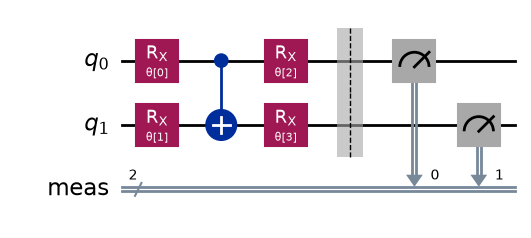

In [6]:
import numpy as np

from qiskit.circuit.library import n_local

#  Create an n_local circuit
#    - 3 qubits
#    - rotation blocks: RX gates
#    - entanglement: linear
circuit= n_local(
    num_qubits=2,
    rotation_blocks='rx',
    entanglement_blocks='cx',
    entanglement='linear',
    reps=1  # number of alternating layers
)

# The circuit is parametrized, so we will define the parameter values for execution
param_values = np.random.rand(circuit.num_parameters)


#Assign values to parameters
#assign_parameters() replaces symbolic parameters with numeric values.
#bound_circuit = circuit.assign_parameters(param_values)


#bound_circuit.measure_all()
circuit.measure_all()

#bound_circuit.draw("mpl")
circuit.draw("mpl")

In [7]:
from qiskit.transpiler import generate_preset_pass_manager


pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(circuit)
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict({'rz': 12, 'sx': 8, 'measure': 2, 'cx': 1, 'barrier': 1})


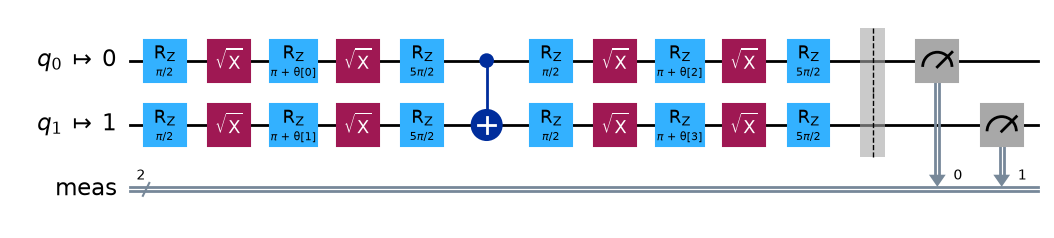

In [8]:
isa_circuit.draw("mpl")

> ### STEP 3:Initialize the IBM Quantum Sampler

mode can be anyone of the values: 
- batch, 
- session, and 
- job execution mode

In [9]:
from qiskit_ibm_runtime import SamplerV2 as Sampler
sampler = Sampler(mode=backend)

> ### STEP 4. Invoke Sampler and get results

Invokes the run() method to generate the output. 

In [10]:
job = sampler.run([(isa_circuit, param_values)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 5a9b9e2a-cb21-47a8-ac53-01c7580c0d25
>>> Job Status: JobStatus.RUNNING


In [11]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: JobStatus.RUNNING


In [12]:

result = job.result()
# Get results for the first (and only) PUB
pub_result = result[0]
# Get counts from the classical register "meas".
print(
    f" >> First five results for the meas output register: "
    f"{pub_result.data.meas.get_bitstrings()[:5]}"
)

 >> First five results for the meas output register: ['10', '11', '00', '00', '00']


# To obtain the results from Sampler, use the 

> ### PubResult.data.meas.get_counts() function, 

Return a dict of measurements in the form of bitstrings as keys and counts as their corresponding values.

{'10': 203, '11': 147, '00': 599, '01': 75}


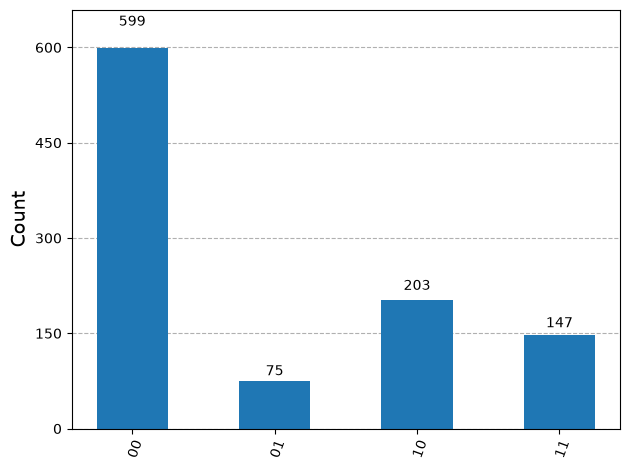

In [13]:
data= pub_result.data
counts_result=data.meas.get_counts()
print(counts_result)

from qiskit.visualization import plot_histogram
plot_histogram(counts_result)

># Estimator

https://quantum.cloud.ibm.com/docs/en/guides/get-started-with-estimator

https://quantum.cloud.ibm.com/docs/en/guides/estimator-examples

Computes the expectation values for one or more observables with respect to states prepared by quantum circuits

The circuits can be parametrized, as long as the parameter values are also provided as input to the primitive.

**NOTE:** 

Has several built-in error mitigation and suppression techniques, including 

- Dynamical decoupling, 
- Pauli-twirling, 
- gate-folding ZNE, PEA, and PEC. 

It also supports a resilience_level option that allows you to easily configure the cost and accuracy tradeoff.

> ### STEP 1: Intialize an account

In [14]:
backend.backend_name

'fake_manila'

> ### STEP 2. Create a circuit and an observable

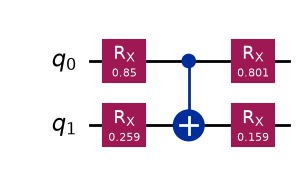

In [15]:
#  Create an n_local circuit
#    - 3 qubits
#    - rotation blocks: RX gates
#    - entanglement: linear
circuit= n_local(
    num_qubits=2,
    rotation_blocks='rx',
    entanglement_blocks='cx',
    entanglement='linear',
    reps=1  # number of alternating layers
)

# The circuit is parametrized, so we will define the parameter values for execution
param_values = np.random.rand(circuit.num_parameters)


#Assign values to parameters
#assign_parameters() replaces symbolic parameters with numeric values.
bound_circuit = circuit.assign_parameters(param_values)


#bound_circuit.measure_all()


bound_circuit.draw("mpl")
#circuit.draw("mpl")

In [16]:
from qiskit.quantum_info import SparsePauliOp
observables_labels = ["ZZ","IZ"]

observables = [SparsePauliOp(label) for label in observables_labels]
print(observables)

[SparsePauliOp(['ZZ'],
              coeffs=[1.+0.j]), SparsePauliOp(['IZ'],
              coeffs=[1.+0.j])]


In [17]:
from qiskit.transpiler import generate_preset_pass_manager

pm = generate_preset_pass_manager(optimization_level=1, backend=backend)
isa_circuit = pm.run(bound_circuit)
isa_observable = [ observable.apply_layout(isa_circuit.layout) for observable in observables  ]
print(f">>> Circuit ops (ISA): {isa_circuit.count_ops()}")

>>> Circuit ops (ISA): OrderedDict({'rz': 12, 'sx': 8, 'cx': 1})


> ### STEP 3. Initialize the IBM Quantum Estimator

In [18]:
backend

In [19]:
from qiskit_ibm_runtime import EstimatorV2 as Estimator

estimator = Estimator(mode=backend)

> ### STEP 4. Invoke Estimator and get results

In [20]:
job = estimator.run([(isa_circuit, isa_observable)])
print(f">>> Job ID: {job.job_id()}")
print(f">>> Job Status: {job.status()}")

>>> Job ID: 67d74b64-3f04-418b-8658-e5011788a442
>>> Job Status: JobStatus.RUNNING


In [21]:
print(f">>> Job Status: {job.status()}")

>>> Job Status: JobStatus.RUNNING


In [22]:
result = job.result()
print(f">>> {result}")
print(f"  > Expectation value: {result[0].data.evs}")
print(f"  > Metadata: {result[0].metadata}")

>>> PrimitiveResult([PubResult(data=DataBin(evs=np.ndarray(<shape=(2,), dtype=float64>), stds=np.ndarray(<shape=(2,), dtype=float64>), shape=(2,)), metadata={'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}})], metadata={'version': 2})
  > Expectation value: [0.58447266 0.44726562]
  > Metadata: {'target_precision': 0.015625, 'shots': 4096, 'circuit_metadata': {}}
